# Análisis del dataset 

Una vez lista la limpieza y los cálculos estadísticos, podemos comenzar con el análisis de la información para encontrar insights importantes para ConnectaTel.

Recordemos las **preguntas de negocio**

- ¿Qué segmentos de clientes muestran mayor o menor uso de llamadas y mensajes?
- ¿Qué usuarios presentan valores atípicos que puedan indicar comportamientos inusuales, fraude o errores de registro?
- ¿Cómo varía el uso según la edad y el tipo de plan contratado?
- ¿Qué patrones pueden ayudar a diseñar mejores planes, optimizar la oferta y mejorar la satisfacción del cliente?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/user_profile.csv")

In [5]:
# Breve visualización del dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  3999 non-null   int64  
 1   first_name               3999 non-null   str    
 2   last_name                3999 non-null   str    
 3   age                      3999 non-null   float64
 4   city                     3999 non-null   str    
 5   plan                     3999 non-null   str    
 6   cant_mensajes            3999 non-null   int64  
 7   cant_caracteres          3999 non-null   float64
 8   cant_llamadas            3999 non-null   int64  
 9   cant_min_llamada         3999 non-null   float64
 10  year                     3959 non-null   float64
 11  reg_date                 3959 non-null   str    
 12  churn_date               466 non-null    str    
 13  limite_cant_llamadas     3999 non-null   int64  
 14  limite_cant_min_llamada  3999 non-n

## Segmentación por edad
Se dividirán a los clientes en segmentos de a cuerdo a su edad y uso para poder tener una fuente de análisis más resumida y limpia

In [6]:
df['grupo_edad'] = pd.cut( # Recibe 4 argumentos:
    df['age'],                  # La columna que quiero segmentar
    bins=[0, 30, 60, 100],      # Los límites definidos en 3 intervalos 
    labels=['Joven', 'Adulto', 'Adulto Mayor'], # La etiqueta de cada intervalo en el mismo orden
    include_lowest=True         # Incluye el límite inferior de cada intervalo (por defecta False)
)

In [7]:
df.head(3)

,user_id,first_name,last_name,age,city,plan,cant_mensajes,cant_caracteres,cant_llamadas,cant_min_llamada,year,reg_date,churn_date,limite_cant_llamadas,limite_cant_min_llamada,limite_cant_mensajes,limite_cant_caracteres,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,Basico,7,258.0,3,23.70,2022.0,2022-01-01 00:00:00+00:00,NaN,3,23.70,7,258.0,Adulto
1,10001,Mateo,Torres,53.0,Desconocido,Basico,5,226.0,10,33.18,2022.0,2022-01-01 06:34:17.914478619+00:00,NaN,10,33.18,5,226.0,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,Basico,5,225.0,2,10.74,2022.0,2022-01-01 13:08:35.828957239+00:00,NaN,2,10.74,5,225.0,Adulto


Se segmentó a los clientes por edad con los títulos de *joven* (0 a 30 años), *adulto* (30 a 60 años) y *adulto mayor* (60 a 100 años).

De esta manera podemos visualizar más rápidamente la cantidad de clientes que tiene ConnectaTel en cada segmento.

In [8]:
def clasify_use(row, call_col, sms_col):
    if (row[call_col] < 5) & (row[sms_col] < 5): # Ambos tienen valor bajo
        return 'Bajo uso'
    elif (row[call_col] >= 10) | (row[sms_col] >= 10): # Al menos uno alto 
        return 'Alto uso'
    else:
        return 'Medio uso'

In [9]:
df['grupo_uso'] = df.apply(lambda row: clasify_use(row, 'limite_cant_llamadas', 'limite_cant_mensajes'), axis = 1)

In [10]:
df.head(3)

,user_id,first_name,last_name,age,city,plan,cant_mensajes,cant_caracteres,cant_llamadas,cant_min_llamada,year,reg_date,churn_date,limite_cant_llamadas,limite_cant_min_llamada,limite_cant_mensajes,limite_cant_caracteres,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,Basico,7,258.0,3,23.70,2022.0,2022-01-01 00:00:00+00:00,NaN,3,23.70,7,258.0,Adulto,Medio uso
1,10001,Mateo,Torres,53.0,Desconocido,Basico,5,226.0,10,33.18,2022.0,2022-01-01 06:34:17.914478619+00:00,NaN,10,33.18,5,226.0,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,Basico,5,225.0,2,10.74,2022.0,2022-01-01 13:08:35.828957239+00:00,NaN,2,10.74,5,225.0,Adulto,Medio uso


Se creó una columna que clasifica a los clientes por niveles de uso *bajo*, *medio* y *alto* de acuerdo a la cantidad de usos que le dieron tanto a llamadas como a mensajes.

En este caso se sabe por el estudio de los histogramas y boxplot que se han usado más el servicio de mensajería que de llamadas, podemos tomar la libertad de dar la opción en el alto uso de que baste con que alguno de los 2 servicios sea mayor o igual a 10 en el uso winsorizado para considerarlo como alto uso 

In [11]:
heavy_users = df[(df['cant_llamadas'] >= 10) | (df['cant_mensajes'] >= 12)]
print(f"Total heavy users: {len(heavy_users)}")
print(f"\nDistribución por plan:")
print(heavy_users['plan'].value_counts())
print(f"\nDistribución por ciudad:")
print(heavy_users['city'].value_counts())

Total heavy users: 114

Distribución por plan:
plan
Basico     77
Premium    37
Name: count, dtype: int64

Distribución por ciudad:
city
Bogotá         25
Medellín       18
Desconocido    16
CDMX           16
Cali           14
MTY            13
GDL            12
Name: count, dtype: int64


El Dataset Tiene registro de **114 Heavy Users** Repartidos entre el plan básico (77 usuarios) y el premium (37 usuarios) concentrando la mayoría en Bogotá (25 usuarios) seguido de Medellín (18 usuarios)

## Revisión de ciudades imputadas como desconocidas

In [12]:
desconocido = df[df['city'] == 'Desconocido']
conocido = df[df['city'] != 'Desconocido']

print("=== Plan ===")
print("Desconocido:", desconocido['plan'].value_counts(normalize=True).round(3).to_dict())
print("Conocido:   ", conocido['plan'].value_counts(normalize=True).round(3).to_dict())

print("\n=== Grupo edad ===")
print("Desconocido:", desconocido['grupo_edad'].value_counts(normalize=True).round(3).to_dict())
print("Conocido:   ", conocido['grupo_edad'].value_counts(normalize=True).round(3).to_dict())

=== Plan ===
Desconocido: {'Basico': 0.648, 'Premium': 0.352}
Conocido:    {'Basico': 0.649, 'Premium': 0.351}

=== Grupo edad ===
Desconocido: {'Adulto': 0.504, 'Adulto Mayor': 0.287, 'Joven': 0.209}
Conocido:    {'Adulto': 0.501, 'Adulto Mayor': 0.288, 'Joven': 0.211}


En la columna *city* se identificaron 565 registros (14.1%) sin ciudad válida en el dataset crudo (469 nulos + 96 con valor '?'), unificados como 'Desconocido'. Un análisis comparativo de distribución por plan y grupo de edad confirma que el faltante es aleatorio (MCAR): las proporciones en el grupo Desconocido son estadísticamente equivalentes a las del resto del dataset (diferencias máximas de 0.3 puntos porcentuales). Esto implica que:

- Las conclusiones agregadas sobre planes y grupos de edad no están sesgadas por este faltante.
- El análisis geográfico se realiza sobre los 3,434 usuarios con ciudad conocida, que constituyen una muestra representativa.
- Se recomienda revisar el flujo de captura para reducir esta proporción en futuras extracciones, aunque no se identifica un patrón sistemático que apunte a una causa específica.

## Inicio del análisis

### Segmentación de clientes por uso

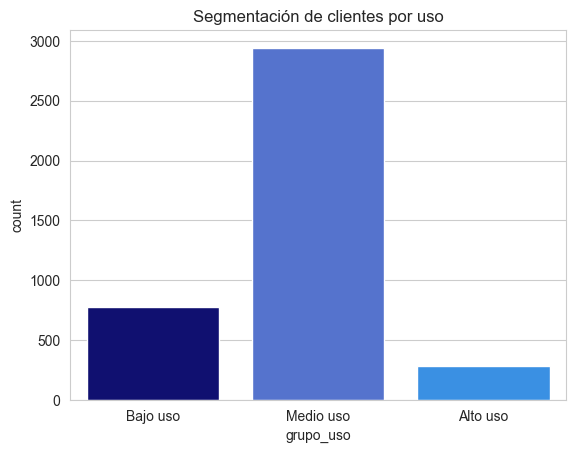

In [34]:
orden = ['Bajo uso', 'Medio uso', 'Alto uso']
sns.countplot(data=df, x='grupo_uso', hue='grupo_uso', order=orden, palette=['royalblue', 'dodgerblue', 'navy'], legend=False, dodge=False).set(
    title = 'Segmentación de clientes por uso'
)
sns.set_style('whitegrid')

Predomina el medio uso por demasiado, eso quiere decir que los servicios de llamadas y mensajes se usan más de 5 veces pero menos de 10 veces cada mes.

El alto uso es mínimo, eso indica que tenemos un pequeño grupo de personas que aprovechan al máximo los límites del plan que contrataron.

El bajo uso tiene un uso un poco más moderado que el alto, pero es bajo a comparación del medio uso, esto podría indicar que hay un grupo de personas que quizá no están conscientes de todos los beneficios que tiene su plan o quizá el plan básico tiene más de lo que necesitan

### Segmentación de clientes por edad

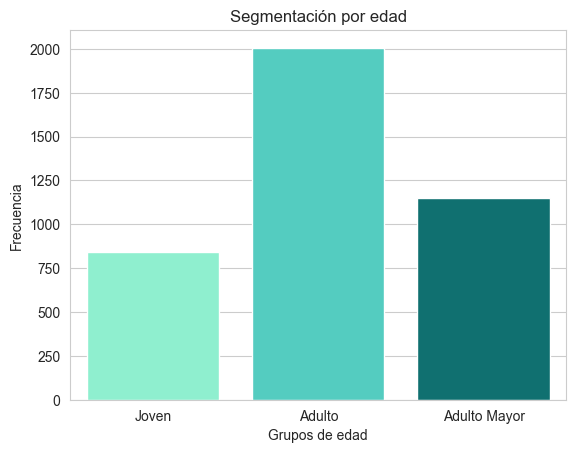

In [65]:
sns.countplot(data=df, x='grupo_edad', hue='grupo_edad', 
              palette=['aquamarine', 'turquoise', 'teal'], 
              legend=False, dodge=False).set(
                  title='Segmentación por edad',
                  xlabel= 'Grupos de edad',
                  ylabel= 'Frecuencia'
                  )
sns.set_style('whitegrid')

Como se esperaba, el segmento de los **adultos** (entre 30 y 60 años) dominan entre todos los clientes registrados hasta el año 2024.

En cuanto a los jóvenes es de esperarse que sean el segmento más reducido por su situación económica y personal.

Los adultos mayores, como se había mencionado anteriormente si adquieren estos servicios y quizá no aprovechan lo mejor posible estos servicios, pero están dispuestos a pagar más por mejor calidad, lo que se refleja en su mayor concentración en el plan Premium en comparación con los otros segmentos.

### Comparación de grupos de uso con grupos de edad

[Text(0.5, 1.0, 'Segmentación de uso por edad'),
 Text(0.5, 0, 'Grupos edad'),
 Text(0, 0.5, 'Frecuencia')]

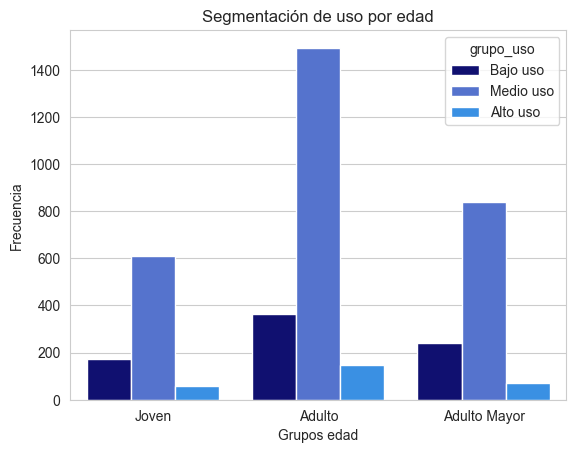

In [49]:
sns.countplot(data=df, x='grupo_edad', hue='grupo_uso', 
              hue_order=['Bajo uso', 'Medio uso', 'Alto uso'], 
              palette=['navy', 'royalblue', 'dodgerblue']).set(
    title='Segmentación de uso por edad',
    xlabel= 'Grupos edad',
    ylabel= 'Frecuencia'
)

In [16]:
df.groupby(['grupo_edad', 'grupo_uso']).size()

grupo_edad    grupo_uso
Joven         Alto uso       59
              Bajo uso      171
              Medio uso     611
Adulto        Alto uso      148
              Bajo uso      365
              Medio uso    1494
Adulto Mayor  Alto uso       71
              Bajo uso      242
              Medio uso     838
dtype: int64

El patrón de uso es el mismo pero a diferente escala sugiriendo que el nivel de uso no está determinado por la edad sino por otros factores como el plan contratado o el perfil del cliente.

Por otro lado, los adultos mayores tienen proporcionalmente el mayor bajo uso (242 de 1151 registros en total) que los otros segmentos (joven: 171 de 841 registros en total y adulto 365 de 2007 registros en total)

### Uso de mensajería según el grupo de edad

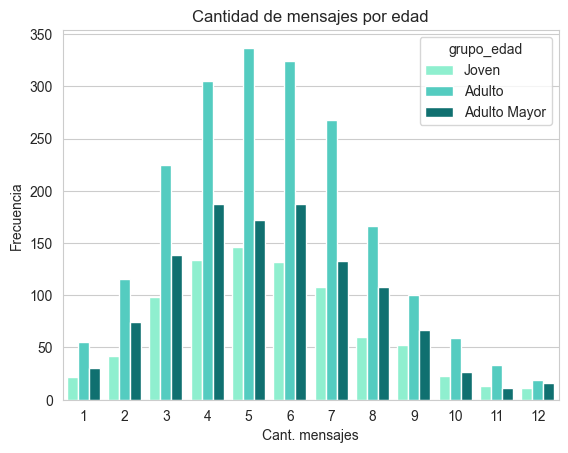

In [66]:
sns.countplot(data=df, x='limite_cant_mensajes', hue='grupo_edad', 
              palette=['aquamarine', 'turquoise', 'teal']).set(
                  title= 'Cantidad de mensajes por edad', 
                  xlabel= 'Cant. mensajes',
                  ylabel= 'Frecuencia'
              )
sns.set_style('whitegrid')

In [18]:
proporciones_mensajes = df.groupby('grupo_edad')['limite_cant_mensajes'].apply(
    lambda x: (x >= 8).sum() / len(x)
)
print('Proporciones_mensajes superiores a 8:')
print(proporciones_mensajes)

Proporciones_mensajes superiores a 8:
grupo_edad
Joven           0.189061
Adulto          0.187843
Adulto Mayor    0.198957
Name: limite_cant_mensajes, dtype: float64


Los adultos tienen la mayor cantidad de mensajes seguidos por los adultos mayores, concentrando la cantidad entre 4 y 6 mensajes enviados.

Contrario a lo esperado, el nivel de uso de mensajes no varía por grupo de edad.

### Uso de llamadas según el grupo de edad

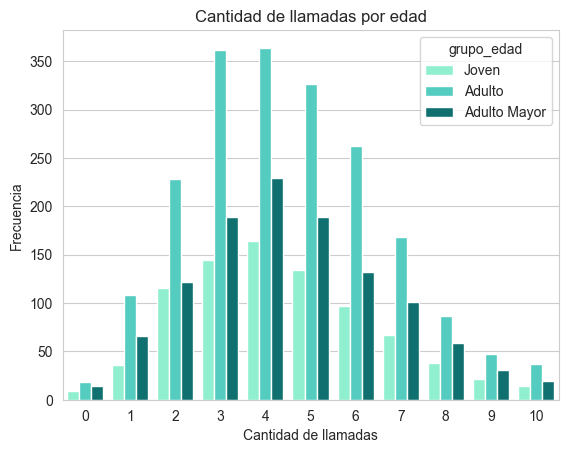

In [68]:
sns.countplot(data=df, x='limite_cant_llamadas', hue='grupo_edad', 
              palette=['aquamarine', 'turquoise', 'teal']).set(
                  title= 'Cantidad de llamadas por edad',
                  xlabel= 'Cantidad de llamadas',
                  ylabel= 'Frecuencia'
              )
sns.set_style('whitegrid')

In [20]:
proporciones = df.groupby('grupo_edad')['limite_cant_llamadas'].apply(
    lambda x: (x >= 6).sum() / len(x)
)
print('Proporción de llamdas superiores a 6:')
print(proporciones)

Proporción de llamdas superiores a 6:
grupo_edad
Joven           0.281807
Adulto          0.299452
Adulto Mayor    0.297133
Name: limite_cant_llamadas, dtype: float64


Los adultos predominan igual las llamadas, sin embargo, como se mencionó anteriormente el uso de las llamadas es menor (entre 3 y 4 veces) a comparación de la cantidad de mensajes (entre 4 y 6 veces).

Contrario a lo esperado, el nivel de uso de llamadas no varía por grupo de edad.

### Tiempo de llamadas por grupos de edad

[Text(0.5, 1.0, 'Minutos en llamada por grupos de edad'),
 Text(0.5, 0, 'Minutos'),
 Text(0, 0.5, 'Frecuencia')]

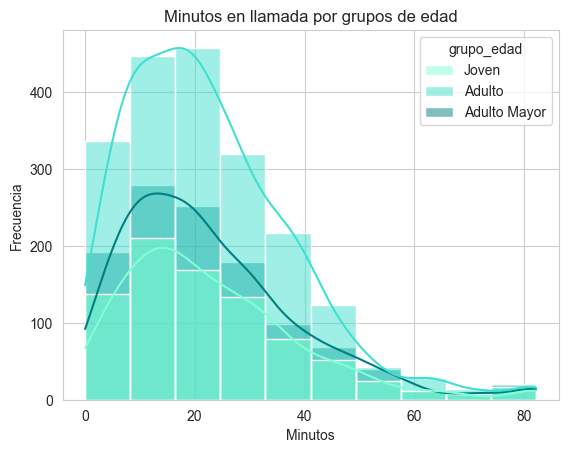

In [75]:
sns.histplot(data=df, x='limite_cant_min_llamada', hue='grupo_edad',
             bins=10, kde=True, 
             palette=['aquamarine', 'turquoise', 'teal']).set(
                 title= 'Minutos en llamada por grupos de edad',
                 xlabel= 'Minutos',
                 ylabel= 'Frecuencia'
             )


Los 3 grupos de edad concentran su tiempo en llamada entre 0 y 20 minutos, sin embargo, *adultos mayores* tienen un subgrupo que muestra que tienden a durar más tiempo en sus llamadas (hasta 82 minutos).

Los tres segmentos realizan llamadas con frecuencia similar (29%). El único diferenciador del segmento adulto mayor es la duración: tienden a sostener llamadas más largas, con usuarios que alcanzan hasta 82 minutos totales al mes.

#### Validación de la winsorización:

In [22]:
# Cuantificar el impacto de la winsorización
for col in ['cant_llamadas', 'cant_mensajes', 'cant_min_llamada', 'cant_caracteres']:
    afectados = (df[col] != df[f'limite_{col}']).sum()
    pct = afectados / len(df) * 100
    print(f'{col}: {afectados} registros modificados ({pct:.2f}%)')

cant_llamadas: 30 registros modificados (0.75%)
cant_mensajes: 39 registros modificados (0.98%)
cant_min_llamada: 40 registros modificados (1.00%)
cant_caracteres: 76 registros modificados (1.90%)


Se comparó la distribución de las columnas crudas (*cant_llamadas, cant_mensajes, cant_min_llamada, cant_caracteres*) contra sus versiones winsorizadas al percentil 99. Las distribuciones resultaron visualmente equivalentes, lo que indica que la cola superior contiene una cantidad marginal (0.75% a 1.90%) de registros y la winsorización no altera el comportamiento típico del usuario. Esto confirma que los análisis posteriores sobre las columnas winsorizadas son representativos de la población real.

### Grupos de edad por ciudad

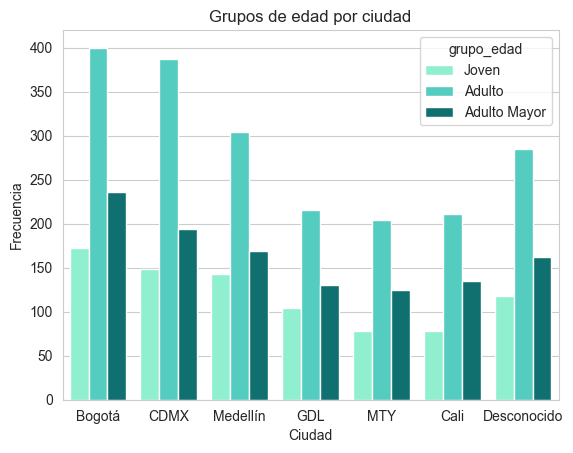

In [77]:
orden = ['Bogotá', 'CDMX', 'Medellín', 'GDL', 'MTY', 'Cali', 'Desconocido']
sns.countplot(data=df, x='city', hue='grupo_edad', order=orden, 
              palette=['aquamarine', 'turquoise', 'teal']).set(
                  title= 'Grupos de edad por ciudad',
                  xlabel= 'Ciudad',
                  ylabel= 'Frecuencia'
              )
sns.set_style('whitegrid')

In [24]:
proporciones = df.groupby('city')['grupo_edad'].value_counts(normalize=True).unstack()
proporciones = proporciones.round(3) * 100

print('Proporciones de grupos de edad por ciudades')
print(proporciones)

Proporciones de grupos de edad por ciudades
grupo_edad   Joven  Adulto  Adulto Mayor
city                                    
Bogotá        21.3    49.5          29.2
CDMX          20.3    53.1          26.6
Cali          18.4    49.8          31.8
Desconocido   20.9    50.4          28.7
GDL           23.1    48.0          28.9
MTY           19.2    50.1          30.7
Medellín      23.2    49.4          27.4


Cali tiene la mayor proporción de adultos mayores (31.8%) comprobable ya que se considera una ciudad ideal para el retiro, las familias tienen en promedio menos hijos que en décadas anteriores, lo que ensancha la base de la población en edades avanzadas y mayor esperanza de vida debido a los avances en el sector de la salud.

Medellín tiene la mayor proporción de jóvenes (23.2%) justificable ya que esta ciudad dispone de gran oferta de becas y créditos para estudios de nivel superior y de igual manera podría considerarse una cuna de emprendimiento, ya que existen programas que apoyan a estos emprendedores con acompañamientos durante sus emprendimientos.

CDMX tiene mayor cantidad de adultos entre sus usuarios (53.1%) ya que la metrópoli centraliza las oportunidades corporativas, gubernamentales y universitarias del país. Esto provoca una fuerte migración interna de jóvenes profesionistas (de 20 a 30 años) que llegan a la ciudad y, con el paso de los años, se quedan y establecen en el rango de los 30 a 60 años.

**Fuentes:**
- INEGI. Censo de Población y Vivienda 2020 — CDMX
- Alcaldía de Cali. Personas mayores en Cali 2023
- Cámara de Comercio de Medellín. Ley 1780 de Emprendimiento Juvenil

### Planes por ciudad

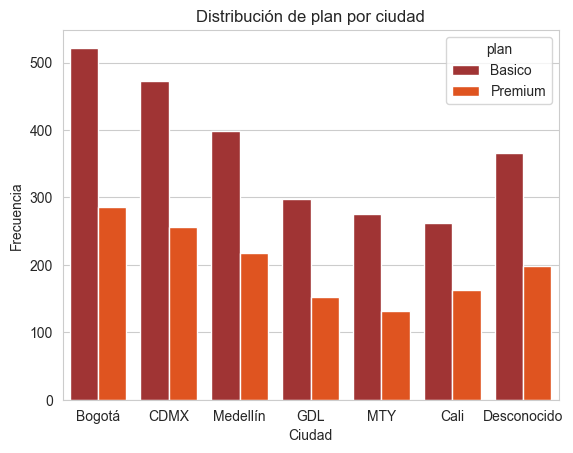

In [81]:
orden = ['Bogotá', 'CDMX', 'Medellín', 'GDL', 'MTY', 'Cali', 'Desconocido']
sns.countplot(data=df, x='city', hue='plan', order=orden, 
              palette=['firebrick', 'orangered']).set(
                  title= 'Distribución de plan por ciudad',
                  xlabel= 'Ciudad',
                  ylabel= 'Frecuencia'
              )
sns.set_style('whitegrid')

In [26]:
proporciones = df.groupby('city')['plan'].value_counts(normalize=True).unstack()
proporciones = proporciones.round(3) * 100
print(proporciones)

plan         Basico  Premium
city                        
Bogotá         64.6     35.4
CDMX           64.9     35.1
Cali           61.8     38.2
Desconocido    64.8     35.2
GDL            66.2     33.8
MTY            67.6     32.4
Medellín       64.6     35.4


Como se mencionó anteriormente, los adultos mayores tienden a no explotar al máximo los servicios contratados, pero prefieren pagar más por calidad, esta gráfica termina de confirmar la hipótesis, poniendo a Cali (ciudad con mayor cantidad de adultos mayores de la lista) como la ciudad con mayor proporción de planes premium contratados.

En el caso del top 3 mencionado anteriormente, CDMX y Medellín están muy cercanos en cuanto a la proporción de planes básicos contratados, mientras que la gráfica indica que Bogotá es la ciudad con mayor cantidad de usuarios de plan básico

### Planes por tipo de uso

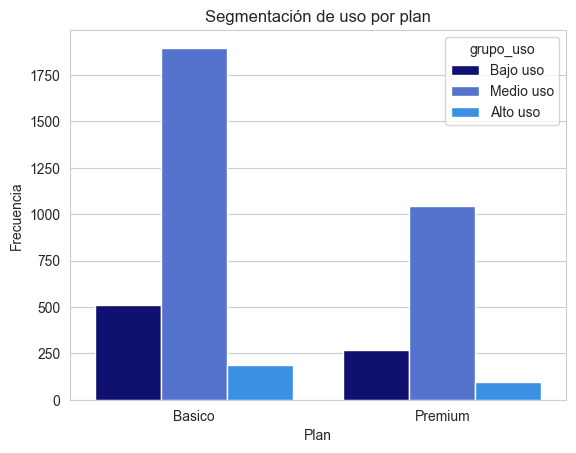

In [84]:
sns.countplot(data=df, x='plan', hue='grupo_uso', 
              hue_order=['Bajo uso', 'Medio uso', 'Alto uso'], 
              palette=['navy', 'royalblue', 'dodgerblue']).set(
                  title='Segmentación de uso por plan',
                  xlabel= 'Plan',
                  ylabel= 'Frecuencia'
                  )
sns.set_style('whitegrid')

In [28]:
proporciones = df.groupby('plan')['grupo_uso'].value_counts(normalize=True).unstack()
proporciones = proporciones.round(3) * 100
print(proporciones)

grupo_uso  Alto uso  Bajo uso  Medio uso
plan                                    
Basico          7.1      19.7       73.1
Premium         6.6      18.9       74.4


Esta gráfica nos da un hallazgo, estamos conscientes de que el objetivo de contar con múltiples planes es que el catálogo *se adapte lo mejor posible a las necesidades de cada persona* (hablando independientemente de la edad) y estos planes no lo están logrando, tienen un comportamiento similar a pesar de que el plan básico tiene mayor cantidad de uso proporcional en alto uso (7.1%) y bajo uso (19.7%), mientras el plan premium domina proporcionalmente en el medio uso (74.4%), eso indica que el premium no da suficiente o no tiene un diferenciador como para que el resto de segmentos por edad lo quieran adquirir además de los adultos mayores.

A este punto del análisis, se recomienda explorar la creación de planes intermedios o personalizados. Sería más ideal, limitando los planes solo a necesidades de los segmentos de usuarios por uso y edad (ejemplo, un plan solo se mensajería o un plan únicamente de llamadas, etc.)

## Insight ejecutivo

El catálogo actual de ConnectaTel no diferencia el comportamiento de sus usuarios: ambos planes concentran 74% de uso medio, señal de que los planes no están segmentando correctamente la demanda.

**Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmente los datos? ¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

Se identificaron 40 registros con fecha errónea (2026) y valores atípicos (outliers) en la cantidad de mensajes (por encima de 12) y llamadas (por encima de 10) los cuales son datos posibles, no se consideraron imposibles ya que están dentro de los límites de los planes, por lo que se caparon para evitar inflar los datos de manera innecesaria. 

De igual manera se reemplazaron los sentinels (-999) numéricos en edad (55 registros) por la mediana para mantener los registros sin comprometer la calidad de los datos.

Se identificaron 565 registros (14.1% del total) sin información de ciudad: 469 valores nulos originales y 96 con el centinel *'?'*. Estos se unificaron como *'Desconocido'* para mantener visibilidad en análisis agregados. El análisis comparativo confirmó que este faltante es aleatorio (MCAR): las distribuciones por plan y grupo de edad del subconjunto son estadísticamente equivalentes al resto del dataset (diferencias menor a 0.3 puntos porcentuales), por lo que las conclusiones sobre planes, uso y demografía no están sesgadas. Los análisis geográficos se realizaron sobre los 3,434 usuarios con ciudad conocida.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Se identificaron clientes *jóvenes*, *adultos* y *adultos mayores*.

Contrario a lo esperado, la frecuencia de llamadas y mensajes no varía significativamente por grupo de edad, los tres segmentos muestran distribuciones de uso prácticamente idénticas, pero con cantidades diferentes siendo los mensajes más usados (entre 4 y 6 mensajes) que las llamadas (entre 3 y 4 llamadas). 

El único diferenciador confirmado es la duración de llamada: los adultos mayores tienden a sostener llamadas más largas, alcanzando hasta 82 minutos totales al mes.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué? 

El segmento más valioso para ConnectaTel es la combinación **adulto mayor + ciudad con perfil de retiro** (Cali), ya que son los usuarios con *mayor propensión al plan premium y mayor duración de llamada*. 

En segundo lugar, **adultos en CDMX y Bogotá** por *volumen*, son el segmento dominante y el *principal consumidor del plan básico*.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

    - Se identificaron 40 registros con *fecha errónea* (2026) los cuales se reemplazaron a valores nulos para evitar lecturas erróneas en el análisis de los datos.
    - Se identificaron 114 heavy users (uso ≥10 llamadas o ≥12 mensajes), concentrados en el plan básico (67.5%). Geográficamente se distribuyen de forma uniforme, el rango entre la ciudad con más (Bogotá: 25) y la de menos (GDL: 12) es de apenas 13 usuarios, lo que sugiere que el comportamiento de heavy user es transversal y no responde a un patrón regional.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Los planes *básico* y *premium* tienen proporciones de uso prácticamente iguales (73% contra 74% medio de uso), indicando que realmente no existe un diferenciador real que puedan diferenciar los clientes, provocando comportamiento similar independientemente del plan contratado.

Recomiendo usar como clave el segmento por edad, los comportamientos de uso y el contexto de las ciudades donde ConnectaTel presta sus servicios, ya que con investigación externa a los datos disponibles, encontramos motivos por los cuales las ciudades tienen ciertos comportamientos, por ejemplo, Cali tiene mayor cantidad de adulto mayor por sus condiciones ideales para el retiro (explicado brevemente) y por ende mejor candidatos para adquirir el plan premium, mientras CDMX es una metrópoli que concentra una gran cantidad de gente que es nativa y otra gran cantidad de gente que migra en busca de mejores oportunidades, provocando la concentración de adultos y la dominancia del plan básico.

Adicionalmente, se recomienda a ConnectaTel revisar el flujo de captura de datos de ciudad, ya que el 14.1% de usuarios sin registro geográfico representa una pérdida de visibilidad operativa relevante, aunque el análisis confirma que no introduce sesgo demográfico.

## Análisis ejecutivo

**Problemas detectados en los datos**
- 40 registros con fecha errónea (2026).
- 565 registros (14.1%) sin ciudad válida: 469 nulos originales y 96 con valor '?', unificados como 'Desconocido'.
- 55 registros de edad inexistentes (-999) imputados con la mediana.
- Usuarios con uso atípico alto (≥10 llamadas o ≥12 mensajes) winsorizados para evitar sesgo en el análisis.
- No se detectaron patrones claros de fraude, pero se recomienda monitoreo.

**Segmentos por Edad**
- *Jóvenes*: Entre 18 y 30 años.
- *Adultos*: Entre 30 y 60 años.
- *Adultos mayores*: De 60 años en adelante.


**Segmentos por Nivel de Uso**
- *Bajo uso*: Menos de 5 llamadas y mensajes.
- *Medio uso*: Entre 5 y 10 en alguno de los servicios (domina ambos planes **73-74%**).
- *Alto uso*: 10 o más en cualquiera de los servicios (Al winsorizar se definió un límite hasta 12 mensajes).

Esto sugiere que:
- El patrón de uso es similar entre planes Básico y Premium, por lo que no hay diferenciador real entre ambos.
- La frecuencia de uso no varía por grupo de edad. El único diferenciador es la duración de llamada: adultos mayores tienden a sostener llamadas más largas.
- Cali tiene mayor proporción de adultos mayores y mayor proporción de plan Premium.
- Bogotá, CDMX y Medellín son el top 3 ciudades con mayor cantidad de clientes.


**Recomendaciones**
- Planificar planes adaptados a los diferentes segmentos de acuerdo al contexto de su ubicación y al segmento (Ejemplo: Plan orientado a adultos mayores en Cali, con menor cantidad de llamadas permitidas al mes pero sin restricción de duración por llamada individual, adaptándose a su patrón de uso real).
- Definir un diferenciador clave entre los planes ya existentes, ya que se visualiza un uso proporcionalmente similar, indicando que casi no hay diferencia en el uso.
- El segmento adulto no presenta una necesidad diferenciada evidente en los datos, su uso medio estable dentro del plan básico sugiere que el plan actual les resulta suficiente. Una estrategia de retención para este segmento requeriría datos adicionales fuera del alcance de este análisis (satisfacción, churn rate, competencia).

**Nota metodológica**

 Los valores extremos se acotaron al **percentil 99** para evitar sesgo en métricas agregadas. Se validó que esta corrección *no distorsiona los patrones de uso*: las distribuciones original y ajustada son equivalentes, lo que da confianza en los segmentos identificados.